# Inciso 2

### Importación de librerías.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling
import matplotlib.pyplot as plt
import seaborn as sns

### Ruta, fechas y constantes.

In [2]:
# Dirección
RAIZ = Path("datos_lagos")

# Fechas
FECHAS = {
    'amatitlan': ["2025-01-28", "2025-04-15", "2025-04-28", "2025-11-24", "2026-01-08", "2026-02-02",
                "2026-02-07", "2026-03-29", "2026-04-13", "2026-04-28", "2026-06-19"],
    'atitlan': ["2025-01-18", "2025-04-13", "2025-05-13", "2025-07-17", "2025-11-21", "2025-12-29",
                "2026-02-12", "2026-03-24", "2026-04-13", "2026-04-28", "2026-07-22"]
        }

UMBRAL_CHLA = 12.0
TAMANO_CELDA_METROS = 300  # Cada observación representa una celda de 300 x 300 m
UMBRAL_NDWI_AGUA = 0.0     # Punto de partida; conviene validarlo con muestras locales
UMBRAL_NDVI_TIERRA = 0.20  # Separa vegetación/tierra de superficies con poca vegetación

### Funciones para leer Rasters.

In [3]:
# Función que permite buscar el archivo raster.
def buscar_raster(lago, fecha, banda):
    carpeta = RAIZ / lago
    nombre_esperado = f"{lago}_{fecha}_{banda}".lower()

    archivos = [archivo for archivo in carpeta.iterdir() if archivo.is_file() and archivo.suffix.lower() in {".tif", ".tiff"}
                and archivo.stem.lower() == nombre_esperado]

    return archivos[0]

In [4]:
# Función que permite leer el raster.
def leer_raster_referencia(ruta):
    with rasterio.open(ruta) as src:
        arreglo = (src.read(1, masked=True).astype("float32").filled(np.nan))

        informacion = {
            "height": src.height,
            "width": src.width,
            "transform": src.transform,
            "crs": src.crs
        }

    return arreglo, informacion

In [5]:
# Función que verifica que los rasters sean compatibles.
def leer_y_alinear(ruta, referencia):
    with rasterio.open(ruta) as src:
        origen = src.read(1, masked=True).astype("float32").filled(np.nan)

        misma_grilla = (src.height == referencia["height"] and src.width == referencia["width"]
                        and src.transform.almost_equals(referencia["transform"]) and src.crs == referencia["crs"])

        if misma_grilla:
            return origen

        destino = np.full((referencia["height"], referencia["width"]), np.nan, dtype="float32")

        reproject(source=origen,
            destination=destino,
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=referencia["transform"],
            dst_crs=referencia["crs"],
            src_nodata=np.nan,
            dst_nodata=np.nan,
            resampling=Resampling.bilinear
        )

        return destino

In [6]:
# Función que normaliza la reflectancia.
def convertir_reflectancia(arreglo):
    return arreglo / 10000

# Calcula un índice normalizado evitando divisiones entre cero.
def calcular_indice_normalizado(banda_1, banda_2):
    denominador = banda_1 + banda_2
    return np.divide(banda_1 - banda_2, denominador, out=np.full_like(banda_1, np.nan),
                     where=np.abs(denominador) > 1e-10)

### 2.1) Construcción de una variable objetivo.

In [8]:
resultados = []

for lago, fechas_lago in FECHAS.items():
    for fecha in fechas_lago:

        # Extracción de las bandas y preprocesamiento de las mismas.
        ruta_b03 = buscar_raster(lago, fecha, "B03")
        ruta_b04 = buscar_raster(lago, fecha, "B04")
        ruta_b05 = buscar_raster(lago, fecha, "B05")
        ruta_b08 = buscar_raster(lago, fecha, "B08")

        b03, referencia = leer_raster_referencia(ruta_b03)
        b04 = leer_y_alinear(ruta_b04, referencia)
        b05 = leer_y_alinear(ruta_b05, referencia)
        b08 = leer_y_alinear(ruta_b08, referencia)

        b03 = convertir_reflectancia(b03)
        b04 = convertir_reflectancia(b04)
        b05 = convertir_reflectancia(b05)
        b08 = convertir_reflectancia(b08)

        # Índices espectrales de Sentinel-2.
        ndci = calcular_indice_normalizado(b05, b04)  # (B05 - B04) / (B05 + B04)
        ndvi = calcular_indice_normalizado(b08, b04)  # (NIR - rojo) / (NIR + rojo)
        ndwi = calcular_indice_normalizado(b03, b08)  # (verde - NIR) / (verde + NIR)

        # Cálculo de clorofila-a en µg/L
        chl_a = (826.57 * ndci**3 - 176.43 * ndci**2  + 19.0 * ndci + 4.071)

        # Se truncan los valores.
        chl_a = np.clip(chl_a, 0, 500)

        # Se identifican los píxeles válidos que se agregarán en celdas de 300 x 300 m.
        mascara_valida = (np.isfinite(b03) & np.isfinite(b04) & np.isfinite(b05) & np.isfinite(b08) & np.isfinite(ndci)
                          & np.isfinite(ndvi) & np.isfinite(ndwi)
                          & np.isfinite(chl_a) & (b03 >= 0) & (b04 >= 0) & (b05 >= 0) & (b08 >= 0) & ((b03 + b04 + b05 + b08) > 0))
        filas, columnas = np.where(mascara_valida)

        # Transformación.
        transformacion = referencia["transform"]

        # Coordenadas.
        coordenada_x = (transformacion.c  + (columnas + 0.5) * transformacion.a + (filas + 0.5) * transformacion.b)
        coordenada_y = (transformacion.f + (columnas + 0.5) * transformacion.d + (filas + 0.5) * transformacion.e)

        # La agrupación de 300 x 300 se expresa en metros; por ello el CRS debe ser proyectado.
        if referencia["crs"] is None or not referencia["crs"].is_projected:
            raise ValueError(f"El raster {ruta_b03.name} debe tener un CRS proyectado en metros.")

        # Se asigna cada píxel a una celda espacial fija de 300 x 300 m.
        tabla_pixeles = pd.DataFrame({"x_pixel": coordenada_x, "y_pixel": coordenada_y,
                                       "b03": b03[mascara_valida], "b04": b04[mascara_valida],
                                       "b05": b05[mascara_valida], "b08": b08[mascara_valida],
                                       "ndci": ndci[mascara_valida], "ndvi": ndvi[mascara_valida],
                                       "ndwi": ndwi[mascara_valida], "chl_a_estimada": chl_a[mascara_valida]})
        tabla_pixeles["es_agua"] = (tabla_pixeles["ndwi"] > UMBRAL_NDWI_AGUA).astype("int8")
        tabla_pixeles["es_tierra"] = ((tabla_pixeles["ndwi"] <= UMBRAL_NDWI_AGUA)
                                           & (tabla_pixeles["ndvi"] >= UMBRAL_NDVI_TIERRA)).astype("int8")
        tabla_pixeles["es_otro"] = ((tabla_pixeles["es_agua"] == 0)
                                         & (tabla_pixeles["es_tierra"] == 0)).astype("int8")
        tabla_pixeles["celda_columna"] = np.floor(tabla_pixeles["x_pixel"] / TAMANO_CELDA_METROS).astype("int64")
        tabla_pixeles["celda_fila"] = np.floor(tabla_pixeles["y_pixel"] / TAMANO_CELDA_METROS).astype("int64")

        # Una fila final por celda: medias espectrales y proporción de cada superficie.
        tabla_fecha = (tabla_pixeles.groupby(["celda_fila", "celda_columna"], as_index=False)
                       .agg(b03=("b03", "mean"), b04=("b04", "mean"), b05=("b05", "mean"),
                            b08=("b08", "mean"), ndci=("ndci", "mean"),
                            ndvi=("ndvi", "mean"), ndwi=("ndwi", "mean"),
                            proporcion_agua=("es_agua", "mean"), proporcion_tierra=("es_tierra", "mean"),
                            proporcion_otro=("es_otro", "mean"), chl_a_estimada=("chl_a_estimada", "mean"),
                            pixeles_validos=("chl_a_estimada", "size")))
        columnas_proporcion = ["proporcion_agua", "proporcion_tierra", "proporcion_otro"]
        tabla_fecha["lago"] = lago
        tabla_fecha["fecha"] = pd.to_datetime(fecha)
        tabla_fecha["x"] = (tabla_fecha["celda_columna"] + 0.5) * TAMANO_CELDA_METROS
        tabla_fecha["y"] = (tabla_fecha["celda_fila"] + 0.5) * TAMANO_CELDA_METROS
        tabla_fecha["alta_cianobacteria"] = (tabla_fecha["chl_a_estimada"] >= UMBRAL_CHLA).astype("int8")
        tabla_fecha = tabla_fecha[["lago", "fecha", "celda_fila", "celda_columna", "x", "y",
                                   "b03", "b04", "b05", "b08", "ndci", "ndvi", "ndwi",
                                   "proporcion_agua", "proporcion_tierra",
                                   "proporcion_otro", "chl_a_estimada",
                                   "pixeles_validos", "alta_cianobacteria"]]

        resultados.append(tabla_fecha)

df_respuesta = pd.concat(resultados, ignore_index=True)

Se agregó la proporción de agua, tierra/vegetacion y otros como nuevas variales, ya que pueden ser útiles en los modelos posteriores y además agregan nueva información.

In [9]:
print(f"Observaciones válidas: {len(df_respuesta):,}")
print(f"Umbral utilizado: {UMBRAL_CHLA} µg/L de clorofila-a estimada")
display(df_respuesta.head())

Observaciones válidas: 76,043
Umbral utilizado: 12.0 µg/L de clorofila-a estimada


,lago,fecha,celda_fila,celda_columna,x,y,b03,b04,b05,b08,ndci,ndvi,ndwi,proporcion_agua,proporcion_tierra,proporcion_otro,chl_a_estimada,pixeles_validos,alta_cianobacteria
0,amatitlan,2025-01-28,5315,2515,754650.0,1594650.0,0.132398,0.138658,0.144739,0.184025,0.028587,0.142609,-0.164142,0.018519,0.305556,0.675926,4.217585,108,0
1,amatitlan,2025-01-28,5315,2516,754950.0,1594650.0,0.130221,0.136321,0.138701,0.167145,0.017599,0.104007,-0.123772,0.014815,0.140741,0.844444,4.114031,135,0
2,amatitlan,2025-01-28,5315,2517,755250.0,1594650.0,0.113663,0.115464,0.125672,0.181696,0.062450,0.231583,-0.233339,0.000000,0.422222,0.577778,5.187567,135,0
3,amatitlan,2025-01-28,5315,2518,755550.0,1594650.0,0.073651,0.061644,0.085370,0.208493,0.180371,0.535377,-0.466721,0.000000,0.955556,0.044444,8.618360,135,0
4,amatitlan,2025-01-28,5315,2519,755850.0,1594650.0,0.070550,0.056940,0.081994,0.213464,0.195710,0.567448,-0.491091,0.000000,0.970370,0.029630,9.460658,135,0


### 2.2) Criterio del umbral.

La OMS establece que un rango entre 12–24 µg/L de clorofila-a es el primer nivel de alerta recreativa y reserva niveles superiores para escenarios de mayor riesgo.

A partir de 12 µg/L de clorofila-a se considera que existe predominio de las cianobacterias.

$\textbf{Referencia}$  
https://cdn.who.int/media/docs/default-source/wash-documents/water-safety-and-quality/toxic-cyanobacteria-2/toxic-cyanobacteria-ch5.pdf?sfvrsn=c013ea1b_7&utm_source=chatgpt.com

2.3) Distribución de variable respuesta.

In [10]:
def tabla_distribucion(datos, grupos=None):
    if grupos is None:
        tabla = (datos["alta_cianobacteria"].value_counts().reindex([0, 1], fill_value=0).rename_axis("clase").reset_index(name="observaciones"))
        tabla["porcentaje"] = (100 * tabla["observaciones"] / tabla["observaciones"].sum())

    else:
        tabla = (datos.groupby(grupos + ["alta_cianobacteria"]).size().unstack(fill_value=0).reindex(columns=[0, 1], fill_value=0)
                 .rename(columns={0: "baja_0", 1: "alta_1"}).reset_index())

        tabla["total"] = tabla["baja_0"] + tabla["alta_1"]
        tabla["porcentaje_baja"] = 100 * tabla["baja_0"] / tabla["total"]
        tabla["porcentaje_alta"] = 100 * tabla["alta_1"] / tabla["total"]

    return tabla

In [11]:
distribucion_global = tabla_distribucion(df_respuesta)
distribucion_lago = tabla_distribucion(df_respuesta, ["lago"])
distribucion_fecha = tabla_distribucion(df_respuesta, ["lago", "fecha"])

In [12]:
print("\nDistribución global")
display(distribucion_global.round(2))

print("\nDistribución por lago")
display(distribucion_lago.round(2))

print("\nDistribución por lago y fecha")
display(distribucion_fecha.round(2))


Distribución global


,clase,observaciones,porcentaje
0,0,41961,55.18
1,1,34082,44.82



Distribución por lago


alta_cianobacteria,lago,baja_0,alta_1,total,porcentaje_baja,porcentaje_alta
0,amatitlan,11309,4377,15686,72.10,27.90
1,atitlan,30652,29705,60357,50.78,49.22



Distribución por lago y fecha


alta_cianobacteria,lago,fecha,baja_0,alta_1,total,porcentaje_baja,porcentaje_alta
0,amatitlan,2025-01-28,1235,191,1426,86.61,13.39
1,amatitlan,2025-04-15,1244,182,1426,87.24,12.76
2,amatitlan,2025-04-28,1276,150,1426,89.48,10.52
3,amatitlan,2025-11-24,982,444,1426,68.86,31.14
4,amatitlan,2026-01-08,670,756,1426,46.98,53.02
5,amatitlan,2026-02-02,1226,200,1426,85.97,14.03
6,amatitlan,2026-02-07,858,568,1426,60.17,39.83
7,amatitlan,2026-03-29,957,469,1426,67.11,32.89
8,amatitlan,2026-04-13,1125,301,1426,78.89,21.11
9,amatitlan,2026-04-28,1211,215,1426,84.92,15.08


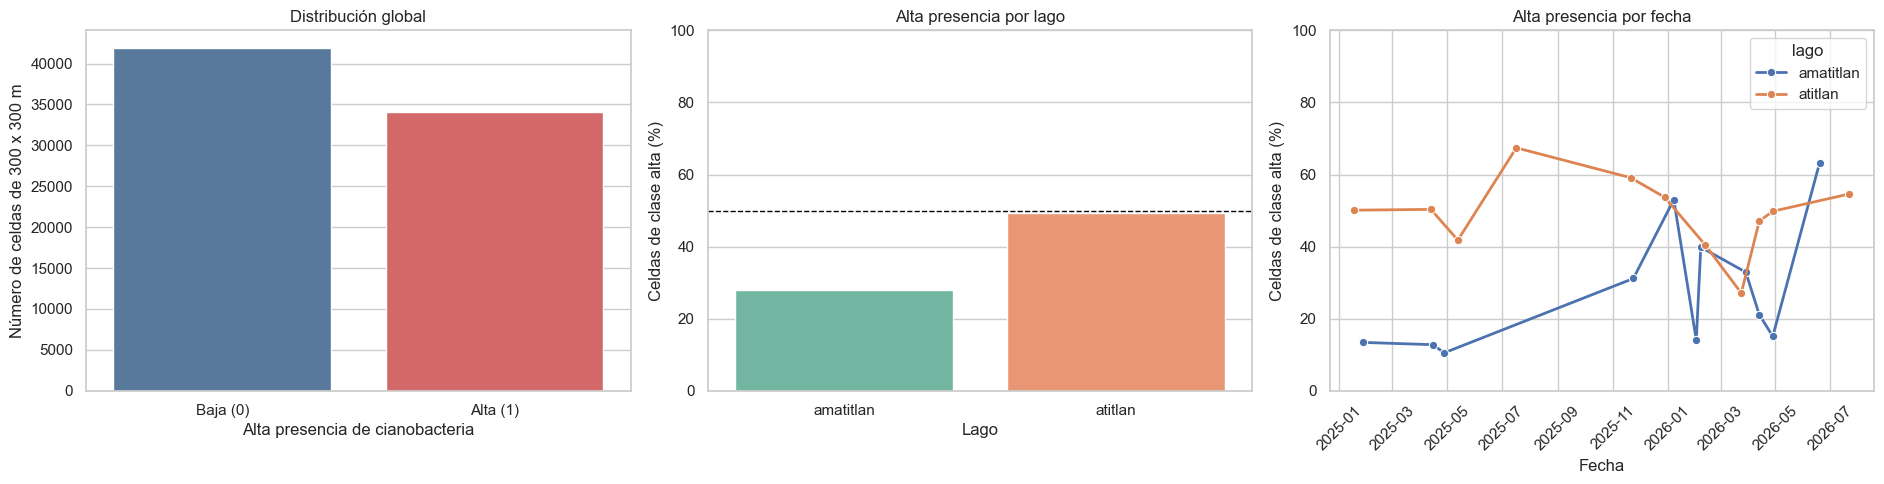

In [13]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(19, 5))

# Gráficos
sns.countplot(data=df_respuesta, x="alta_cianobacteria", hue="alta_cianobacteria", palette={0: "#4C78A8", 1: "#E45756"}, legend=False, ax=axes[0])
axes[0].set_title("Distribución global")
axes[0].set_xlabel("Alta presencia de cianobacteria")
axes[0].set_ylabel("Número de celdas de 300 x 300 m")
axes[0].set_xticks([0, 1], ["Baja (0)", "Alta (1)"])

sns.barplot(data=distribucion_lago, x="lago", y="porcentaje_alta", hue="lago", palette="Set2", legend=False, ax=axes[1])
axes[1].axhline(50, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Alta presencia por lago")
axes[1].set_xlabel("Lago")
axes[1].set_ylabel("Celdas de clase alta (%)")
axes[1].set_ylim(0, 100)

sns.lineplot(data=distribucion_fecha,x="fecha", y="porcentaje_alta", hue="lago", marker="o", linewidth=2, ax=axes[2])
axes[2].set_title("Alta presencia por fecha")
axes[2].set_xlabel("Fecha")
axes[2].set_ylabel("Celdas de clase alta (%)")
axes[2].set_ylim(0, 100)
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

Global: La mayor parte de los lagos tiene concentraciones bajas de clorofila-a.  
Lagos: Ambos lagos tienen la mayor parte con concentraciones bajas de clorofila-a, pero el lago de Atitlán tiene mayor porcentaje.  
Fechas: Los porcentajes de clorofila-a no se mantienen constantes en el tiempo y se tienen vatiaciones de hasta el 34% del porcentaje.

### 2.4) Desbalance.

In [14]:
conteos = (df_respuesta["alta_cianobacteria"].value_counts().reindex([0, 1], fill_value=0))

clase_mayoritaria = conteos.max()
clase_minoritaria = conteos.min()

if clase_minoritaria == 0:
    razon_desbalance = np.inf
else:
    razon_desbalance = clase_mayoritaria / clase_minoritaria

print(f"Clase 0: {conteos[0]:,} observaciones")
print(f"Clase 1: {conteos[1]:,} observaciones")
print(f"Razón mayoritaria/minoritaria: {razon_desbalance:.2f}:1")

Clase 0: 41,961 observaciones
Clase 1: 34,082 observaciones
Razón mayoritaria/minoritaria: 1.23:1


Existe desbalance entre las clases, pero es moderado, ya que la clase minoritaria representa aproximadamente el 38% de los datos.

### 2.5 Variables no predictoras.

Las filas y las columnas de la cuadrícula se descartan como variables directas.  
Las reflectancias medias de B03, B04, B05 y B08, junto con NDVI, NDWI y las proporciones de agua, tierra y otras superficies, se conservan como predictores. `tipo_superficie` es categórica y deberá codificarse dentro del pipeline del modelo.  
La fecha se separa en día, mes y año. NDCI y `chl_a_estimada`, B04 y B05 se conservan en el CSV para trazabilidad, pero deben excluirse del modelo porque construyen directamente la variable objetivo y producirían fuga de información.

### Guardado de datos

In [15]:
df_respuesta['dia'] = df_respuesta['fecha'].dt.day
df_respuesta['mes'] = df_respuesta['fecha'].dt.month
df_respuesta['anio'] = df_respuesta['fecha'].dt.year
df_respuesta = df_respuesta.drop(columns = ["fecha", "celda_fila", "celda_columna"])
df_respuesta.to_csv('datos_predictores.csv', index=False)